In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sb

In [2]:

df = pd.read_csv('customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
 5   cluster                 200 non-null    int64
dtypes: int64(5), str(1)
memory usage: 9.5 KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),cluster
count,200.000000,200.000000,200.000000,200.000000,200.00000
mean,100.500000,38.850000,60.560000,50.200000,2.24500
std,57.879185,13.969007,26.264721,25.823522,1.81423
min,1.000000,18.000000,15.000000,1.000000,0.00000
25%,50.750000,28.750000,41.500000,34.750000,1.00000
50%,100.500000,36.000000,61.500000,50.000000,2.00000
75%,150.250000,49.000000,78.000000,73.000000,4.00000
max,200.000000,70.000000,137.000000,99.000000,5.00000


In [5]:
df.rename(columns={
    'Annual Income (k$)':'income',
    'Spending Score (1-100)':'ss'
},inplace=True)

In [6]:
df.head()

,CustomerID,Gender,Age,income,ss,cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


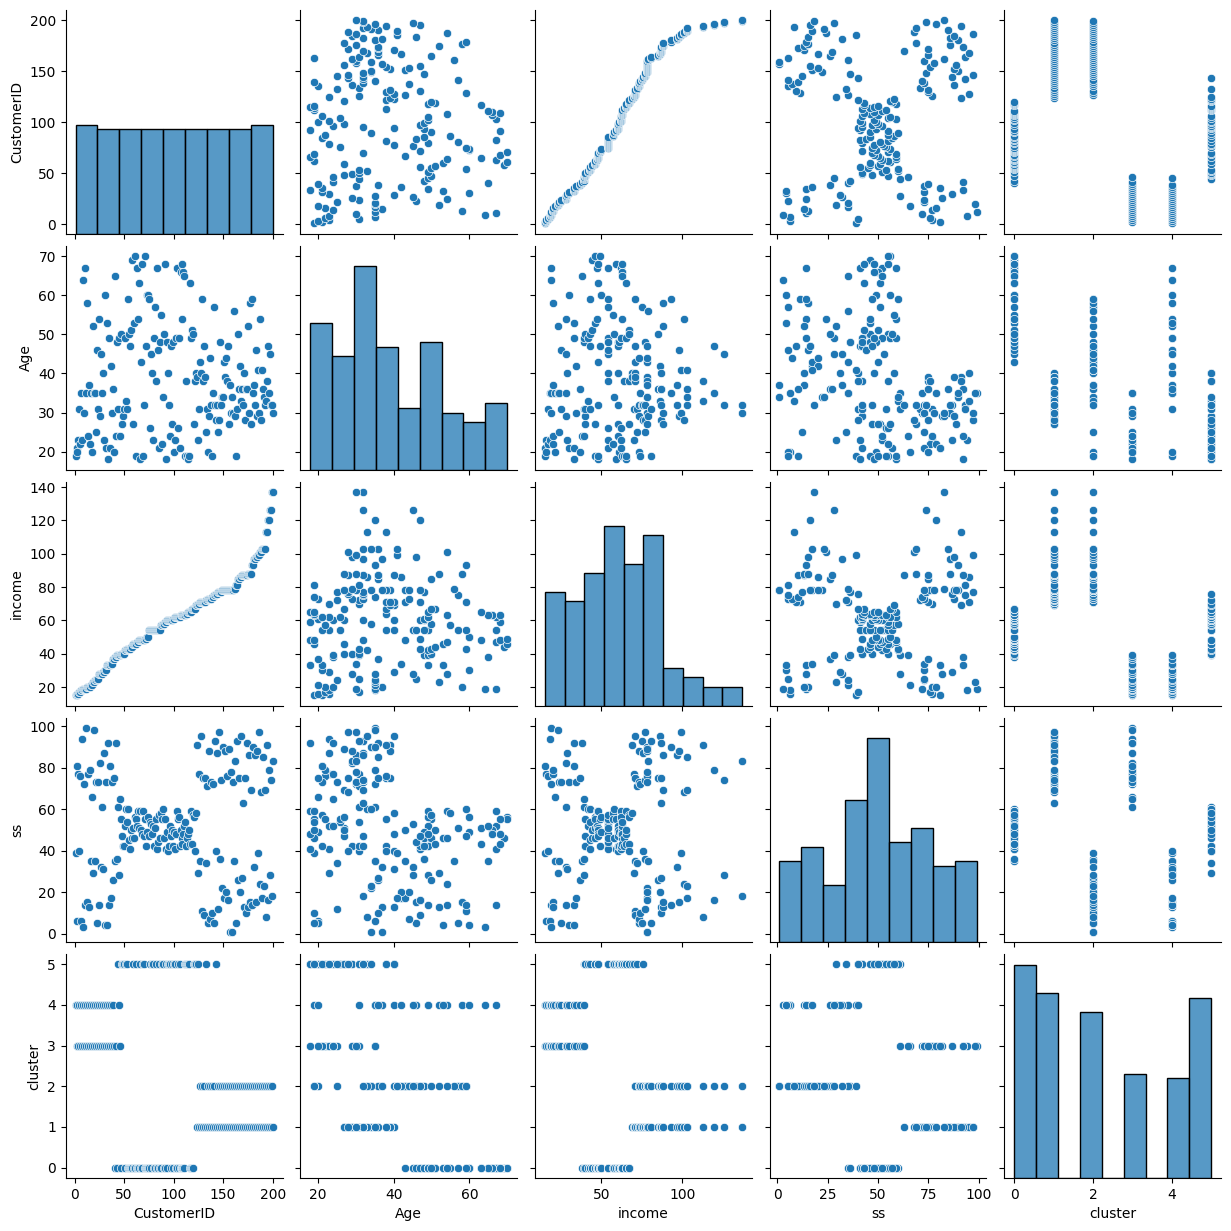

In [7]:
sb.pairplot(df)

In [8]:
df = df.drop(['CustomerID'],axis=1)
df.head()

,Gender,Age,income,ss,cluster
0,Male,19,15,39,4
1,Male,21,15,81,3
2,Female,20,16,6,4
3,Female,23,16,77,3
4,Female,31,17,40,4


<Axes: >

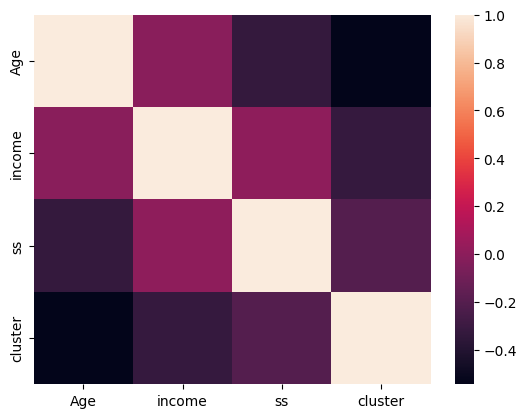

In [9]:
sb.heatmap(df.corr(numeric_only=True))

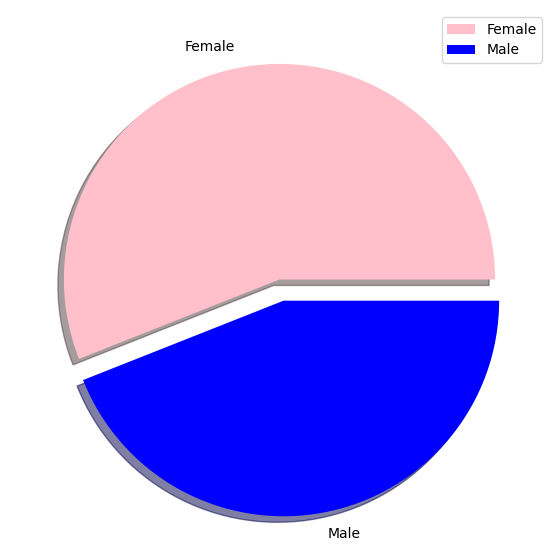

In [10]:
plt.figure(figsize=(7,7))
size = df['Gender'].value_counts()
label = ['Female','Male']
color = ['Pink','Blue']
explode = [0,.1]
plt.pie(size,explode=explode,labels=label,colors=color,shadow=True)
plt.legend()
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  15

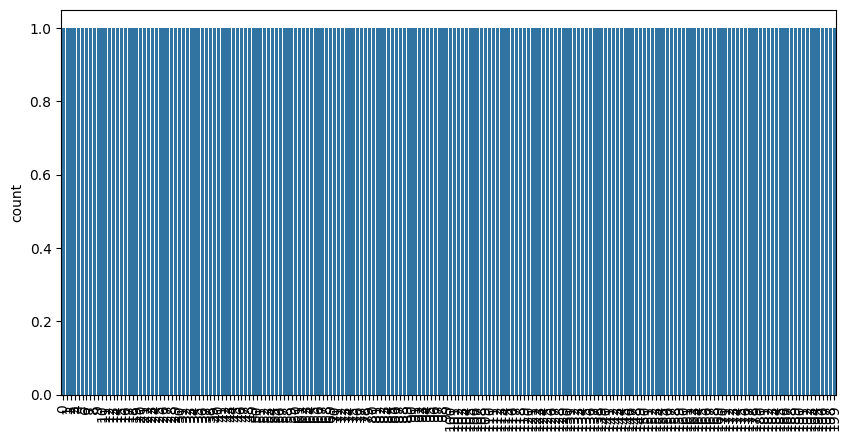

In [11]:
plt.figure(figsize=(10,5))
sb.countplot(df['Age'])
plt.xticks(rotation=90)

<Axes: xlabel='Gender', ylabel='ss'>

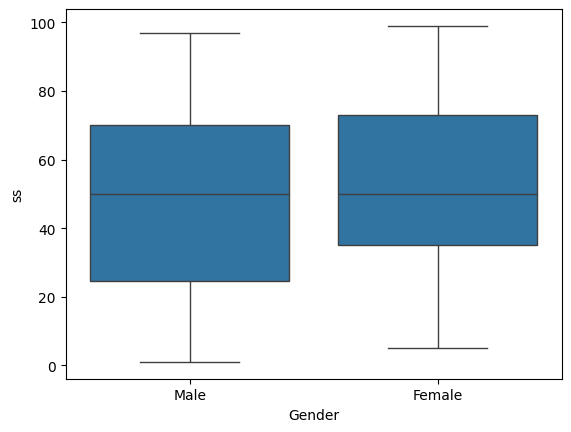

In [12]:
sb.boxplot(x=df['Gender'],y=df['ss'])

<Axes: ylabel='count'>

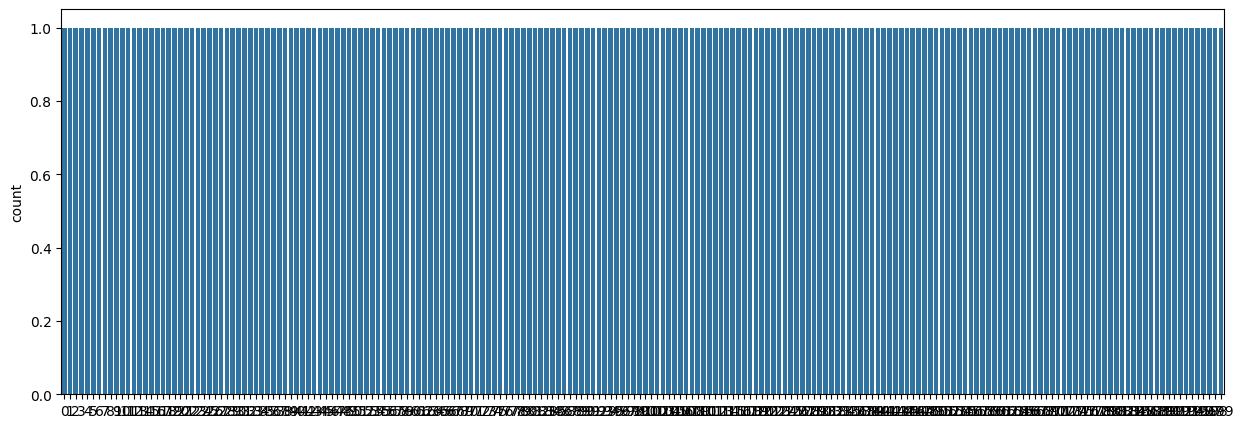

In [13]:
plt.figure(figsize=(15,5))
sb.countplot(df['income'])

Text(0, 0.5, 'Spending Score')

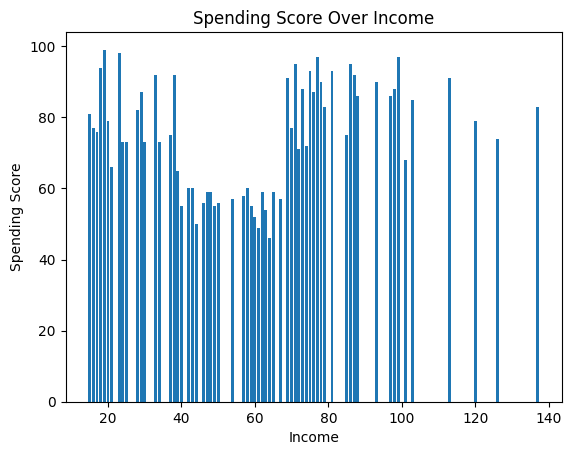

In [14]:
plt.bar(df['income'],df['ss'])
plt.title('Spending Score Over Income')
plt.xlabel('Income')
plt.ylabel('Spending Score')

In [15]:
# plt.scatter(df['income'],df['ss'])
# plt.title('Spending Score Over Income')
# plt.xlabel('Income')
# plt.ylabel('Spending Score')

In [16]:
df.head()

,Gender,Age,income,ss,cluster
0,Male,19,15,39,4
1,Male,21,15,81,3
2,Female,20,16,6,4
3,Female,23,16,77,3
4,Female,31,17,40,4


In [17]:
x = df.iloc[:,[2,3]].values
x.shape

(200, 2)

In [18]:
from sklearn.cluster import DBSCAN
db = DBSCAN(
    eps=3,
    min_samples=4,
    metric='euclidean'
)

In [19]:
model = db.fit(x)

In [23]:
label = model.labels_
label

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  0,  0,  0,  0, -1, -1,  0, -1,  0, -1,  0,  0,
       -1,  0, -1, -1,  0, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  2,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  2,
        3,  3, -1,  3, -1, -1,  4, -1, -1, -1,  4,  5,  4, -1,  4,  5, -1,
        5,  4, -1,  4,  5, -1, -1,  6, -1, -1, -1,  7, -1,  6, -1,  6, -1,
        7, -1,  6, -1,  7, -1,  7, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        8, -1,  8, -1,  8, -1,  8, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [24]:
from sklearn import metrics

sample_cores = np.zeros_like(label,dtype=bool)

sample_cores[db.core_sample_indices_] = True

n_clusters = len(set(label))- 1
print(f'Number of clusters is: {n_clusters}')

Number of clusters is: 9


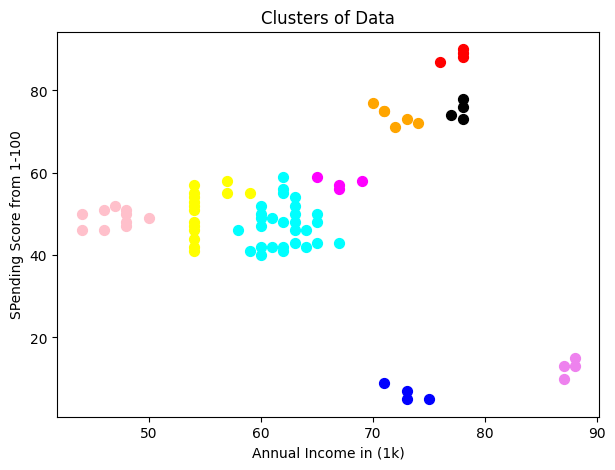

In [27]:
y_means = db.fit_predict(x)

plt.figure(figsize=(7,5))

colors = ['pink','yellow','cyan','magenta','orange','blue','red','black','violet']

for i in range(0,9):
    plt.scatter(x[y_means==i,0],x[y_means==i,1],s=50,c=colors[i])

plt.xlabel('Annual Income in (1k)')
plt.ylabel('SPending Score from 1-100')
plt.title('Clusters of Data')
plt.show()

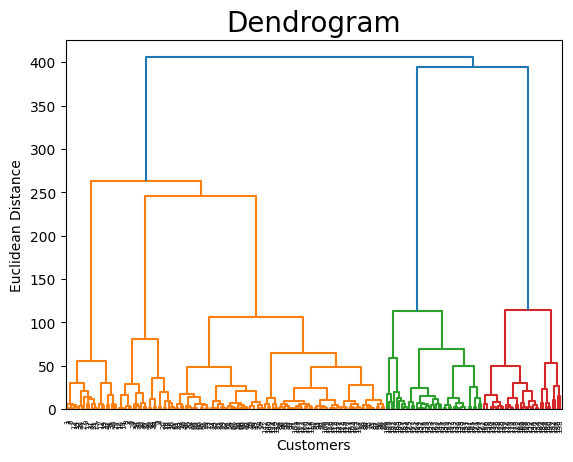

In [28]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(sch.linkage(x,method='ward'))
plt.title('Dendrogram',fontsize=20)
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6460\3109100319.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


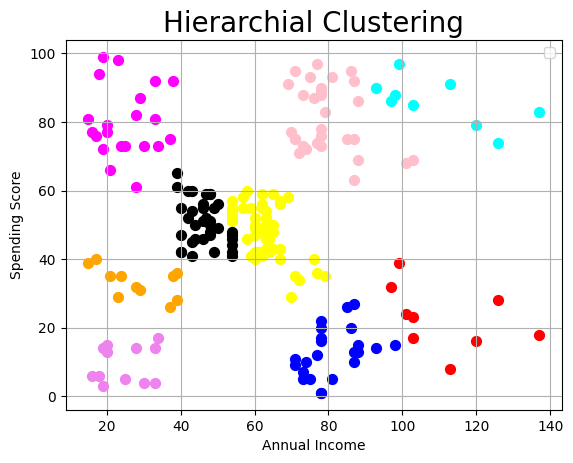

In [30]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=9,#9
    linkage='ward'
)

y_hc = hc.fit_predict(x)

for j in range(0,9):
    plt.scatter(x[y_hc==j,0],x[y_hc==j,1],s=50,c=colors[j])

plt.title('Hierarchial Clustering',fontsize=20)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid()
plt.show()